# Task 3: Customer Segmentation
## Customer Churn Analysis and Prediction — SaiKet Systems Data Analysis Internship

**Task:** 3 of 4 (selected tasks)

---

## 1. Business Problem
Aggregate churn statistics (Task 2) tell the business churn is high, but not **which specific
combinations of customers** are most at risk, or how large / valuable those groups are — the
information needed to prioritize retention spend.

## 2. Objective
Segment customers using **tenure, monthly charges, and contract type** (the three variables the
project brief specifies), calculate churn rate and value metrics per segment, and identify the
highest-risk and highest-value-at-risk groups.

## 3. Segmentation Approach

RFM (Recency-Frequency-Monetary) segmentation is not used here because this is not a retail
transaction dataset — there is no purchase recency or frequency data. Clustering algorithms (e.g.
k-means) were also considered, but were not chosen as the primary method because the project brief
explicitly names the three segmentation variables to use (tenure, monthly charges, contract type),
and those variables are already directly business-interpretable — a rule-based segmentation on them
produces segments a retention team can act on immediately ("month-to-month, high-charge, new
customers"), whereas a clustering solution would need to be translated back into these same terms to
be useful. **Rule-based segmentation** is therefore used: tenure and monthly charges are each split
into three business-meaningful bands, then combined with contract type.


## 4. Import Libraries

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)


## 5. Load Dataset

In [2]:
df = pd.read_csv('../Task_1_Data_Cleaning_and_Preprocessing/Task_1_Cleaned_Dataset.csv')
print(df.shape)
df[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']].head()


(7043, 21)


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
0,7590-VHVEG,1,29.85,29.85,Month-to-month,0
1,5575-GNVDE,34,56.95,1889.50,One year,0
2,3668-QPYBK,2,53.85,108.15,Month-to-month,1
3,7795-CFOCW,45,42.30,1840.75,One year,0
4,9237-HQITU,2,70.70,151.65,Month-to-month,1


## 6. Segment 1 — Tenure Groups

In [3]:
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = ['New (0-12mo)', 'Developing (13-24mo)', 'Established (25-48mo)', 'Loyal (49-72mo)']
df['Tenure_Segment'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True)

tenure_seg_summary = df.groupby('Tenure_Segment', observed=True).agg(
    customer_count=('customerID', 'count'),
    churn_rate_pct=('Churn', lambda x: round(x.mean() * 100, 2)),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
)
tenure_seg_summary['pct_of_customers'] = (tenure_seg_summary['customer_count'] / len(df) * 100).round(2)
tenure_seg_summary = tenure_seg_summary.round(2)
tenure_seg_summary


,customer_count,churn_rate_pct,avg_monthly_charges,avg_tenure,pct_of_customers
Tenure_Segment,,,,,
New (0-12mo),2186,47.44,56.10,4.73,31.04
Developing (13-24mo),1024,28.71,61.36,18.35,14.54
Established (25-48mo),1594,20.39,65.93,36.19,22.63
Loyal (49-72mo),2239,9.51,73.95,63.05,31.79


## 7. Segment 2 — Monthly Charges Groups

In [4]:
charge_bins = [0, 35, 70, 120]
charge_labels = ['Low (<=$35)', 'Medium ($35-$70)', 'High (>$70)']
df['Charges_Segment'] = pd.cut(df['MonthlyCharges'], bins=charge_bins, labels=charge_labels, include_lowest=True)

charges_seg_summary = df.groupby('Charges_Segment', observed=True).agg(
    customer_count=('customerID', 'count'),
    churn_rate_pct=('Churn', lambda x: round(x.mean() * 100, 2)),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
)
charges_seg_summary['pct_of_customers'] = (charges_seg_summary['customer_count'] / len(df) * 100).round(2)
charges_seg_summary = charges_seg_summary.round(2)
charges_seg_summary


,customer_count,churn_rate_pct,avg_monthly_charges,avg_tenure,pct_of_customers
Charges_Segment,,,,,
Low (<=$35),1735,10.89,22.03,28.67,24.63
Medium ($35-$70),1725,23.94,54.84,26.87,24.49
High (>$70),3583,35.36,90.23,36.81,50.87


## 8. Segment 3 — Contract Type

In [5]:
contract_seg_summary = df.groupby('Contract').agg(
    customer_count=('customerID', 'count'),
    churn_rate_pct=('Churn', lambda x: round(x.mean() * 100, 2)),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
)
contract_seg_summary['pct_of_customers'] = (contract_seg_summary['customer_count'] / len(df) * 100).round(2)
contract_seg_summary = contract_seg_summary.round(2)
contract_seg_summary


,customer_count,churn_rate_pct,avg_monthly_charges,avg_tenure,pct_of_customers
Contract,,,,,
Month-to-month,3875,42.71,66.40,18.04,55.02
One year,1473,11.27,65.05,42.04,20.91
Two year,1695,2.83,60.77,56.74,24.07


## 9. Visualizing the Three Base Segments

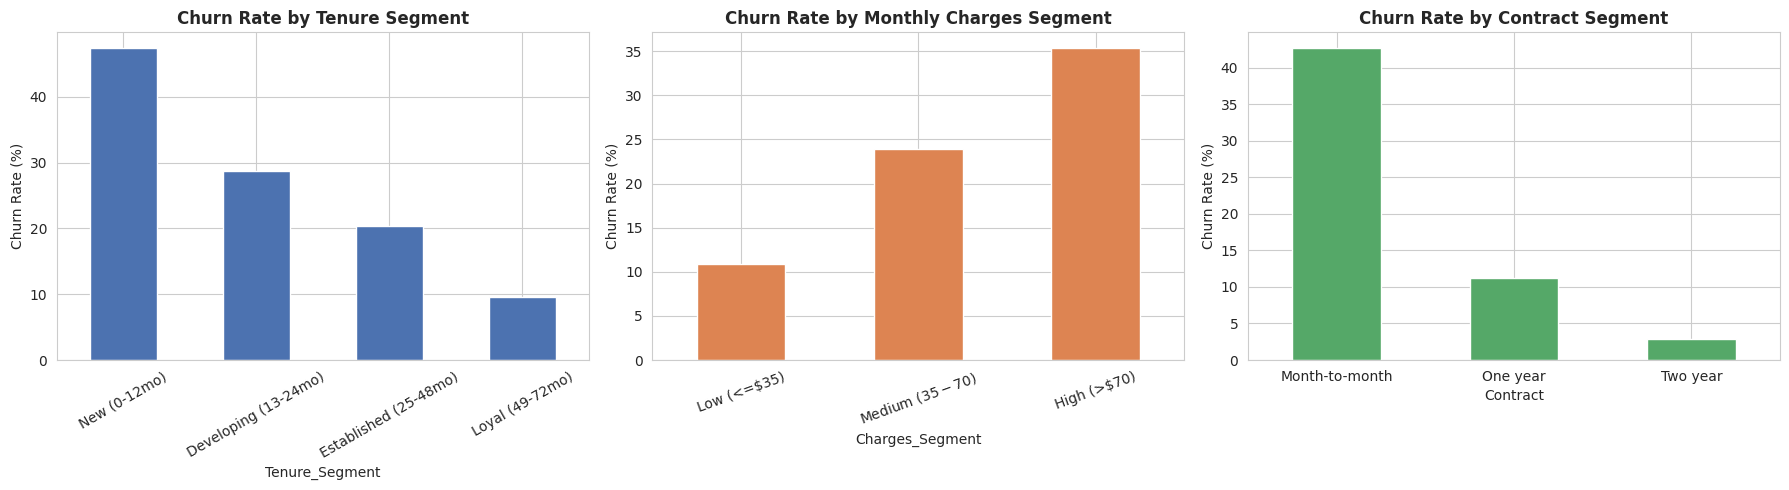

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tenure_seg_summary['churn_rate_pct'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Churn Rate by Tenure Segment', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

charges_seg_summary['churn_rate_pct'].plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Churn Rate by Monthly Charges Segment', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=20)

contract_seg_summary['churn_rate_pct'].plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Churn Rate by Contract Segment', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


**Observation:** Churn risk increases steadily as tenure decreases, as monthly charges
increase, and as contract commitment decreases (month-to-month > one year > two year).

**Business Interpretation:** All three variables move churn risk independently, which motivates
combining them into a single joint segment to find the customers where all three risk factors stack
together.

## 10. Combined Segment: Tenure x Charges x Contract

In [7]:
df['Combined_Segment'] = (df['Tenure_Segment'].astype(str) + ' | ' +
                          df['Charges_Segment'].astype(str) + ' | ' +
                          df['Contract'].astype(str))

combined_summary = df.groupby('Combined_Segment', observed=True).agg(
    customer_count=('customerID', 'count'),
    churn_rate_pct=('Churn', lambda x: round(x.mean() * 100, 2)),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
)
# Only keep segments with a meaningful sample size for reliable churn-rate estimates
combined_summary = combined_summary[combined_summary['customer_count'] >= 30]
combined_summary['pct_of_customers'] = (combined_summary['customer_count'] / len(df) * 100).round(2)
combined_summary = combined_summary.round(2).sort_values('churn_rate_pct', ascending=False)

print(f"Number of combined segments with >=30 customers: {len(combined_summary)}")
combined_summary.head(10)


Number of combined segments with >=30 customers: 29


,customer_count,churn_rate_pct,avg_monthly_charges,avg_tenure,pct_of_customers
Combined_Segment,,,,,
New (0-12mo) | High (>$70) | Month-to-month,856,69.04,83.08,5.01,12.15
Developing (13-24mo) | High (>$70) | Month-to-month,430,49.07,87.64,18.14,6.11
New (0-12mo) | Medium ($35-$70) | Month-to-month,629,45.47,53.56,4.20,8.93
Established (25-48mo) | High (>$70) | Month-to-month,539,41.74,90.87,35.14,7.65
New (0-12mo) | Low (<=$35) | Month-to-month,509,28.88,22.16,3.90,7.23
Loyal (49-72mo) | High (>$70) | Month-to-month,272,28.68,94.62,58.01,3.86
Developing (13-24mo) | Medium ($35-$70) | Month-to-month,196,27.04,55.27,18.26,2.78
Established (25-48mo) | High (>$70) | One year,230,17.83,89.82,37.56,3.27
Developing (13-24mo) | High (>$70) | One year,40,17.50,85.66,19.62,0.57


### Highest-Risk and Lowest-Risk Combined Segments

In [8]:
print("TOP 5 HIGHEST-RISK SEGMENTS:")
print(combined_summary.head(5)[['customer_count', 'churn_rate_pct', 'avg_monthly_charges']])

print("\nTOP 5 LOWEST-RISK SEGMENTS:")
print(combined_summary.tail(5)[['customer_count', 'churn_rate_pct', 'avg_monthly_charges']])


TOP 5 HIGHEST-RISK SEGMENTS:
                                                    customer_count  \
Combined_Segment                                                     
New (0-12mo) | High (>$70) | Month-to-month                    856   
Developing (13-24mo) | High (>$70) | Month-to-m...             430   
New (0-12mo) | Medium ($35-$70) | Month-to-month               629   
Established (25-48mo) | High (>$70) | Month-to-...             539   
New (0-12mo) | Low (<=$35) | Month-to-month                    509   

                                                    churn_rate_pct  \
Combined_Segment                                                     
New (0-12mo) | High (>$70) | Month-to-month                  69.04   
Developing (13-24mo) | High (>$70) | Month-to-m...           49.07   
New (0-12mo) | Medium ($35-$70) | Month-to-month             45.47   
Established (25-48mo) | High (>$70) | Month-to-...           41.74   
New (0-12mo) | Low (<=$35) | Month-to-month                 

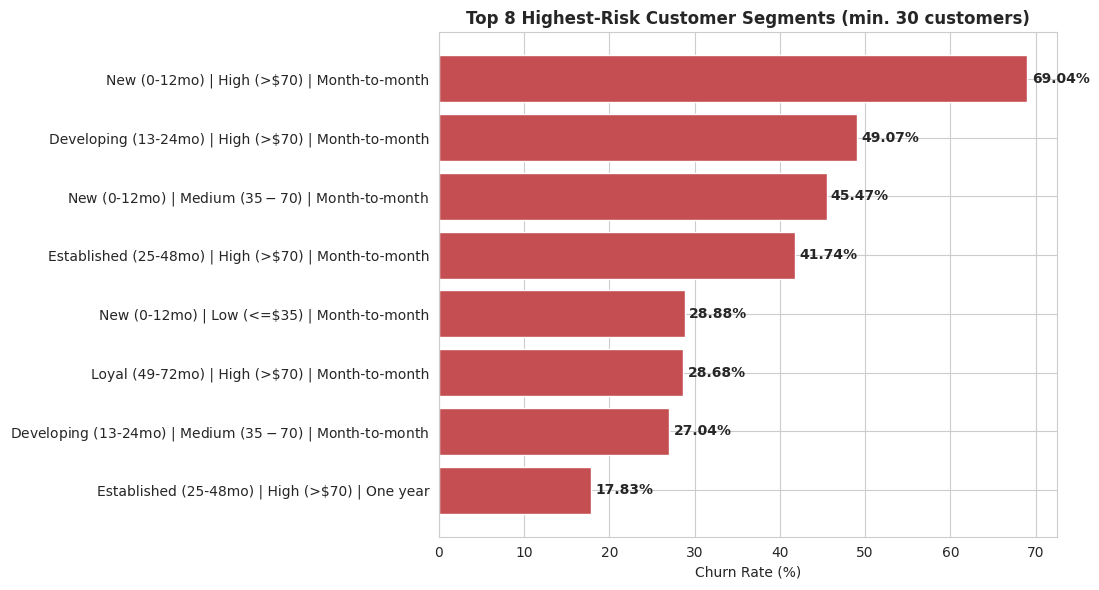

In [9]:
top_risk = combined_summary.head(8)
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_risk.index, top_risk['churn_rate_pct'], color='#C44E52')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Top 8 Highest-Risk Customer Segments (min. 30 customers)', fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top_risk['churn_rate_pct']):
    ax.text(v + 0.5, i, f"{v}%", va='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** The highest-risk segments are consistently **New (0-12mo) customers on
Month-to-month contracts with High (>$70) monthly charges**, with churn rates well above the overall
26.54% baseline. The lowest-risk segments are **Loyal (49-72mo) customers on Two year contracts**.

**Business Interpretation:** Risk is not driven by a single factor but by the *combination* — new,
expensive, uncommitted customers are the group retention campaigns should target first.

## 11. High-Value / High-Risk Priority Framework

In [10]:
median_value = df['MonthlyCharges'].median()
median_tenure_risk_cutoff = 12  # months; low-tenure customers treated as high risk based on Task 2 findings

df['Value_Tier'] = np.where(df['MonthlyCharges'] >= median_value, 'High Value', 'Low Value')
df['Risk_Tier'] = np.where(
    (df['Contract'] == 'Month-to-month') & (df['tenure'] <= median_tenure_risk_cutoff),
    'High Risk', 'Low Risk'
)
df['Priority_Segment'] = df['Value_Tier'] + ' + ' + df['Risk_Tier']

priority_summary = df.groupby('Priority_Segment').agg(
    customer_count=('customerID', 'count'),
    churn_rate_pct=('Churn', lambda x: round(x.mean() * 100, 2)),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
).round(2)
priority_summary['pct_of_customers'] = (priority_summary['customer_count'] / len(df) * 100).round(2)
priority_summary = priority_summary.sort_values('churn_rate_pct', ascending=False)
priority_summary


,customer_count,churn_rate_pct,avg_monthly_charges,pct_of_customers
Priority_Segment,,,,
High Value + High Risk,816,69.73,83.72,11.59
Low Value + High Risk,1178,38.62,40.55,16.73
High Value + Low Risk,2708,24.70,92.63,38.45
Low Value + Low Risk,2341,7.52,38.10,33.24


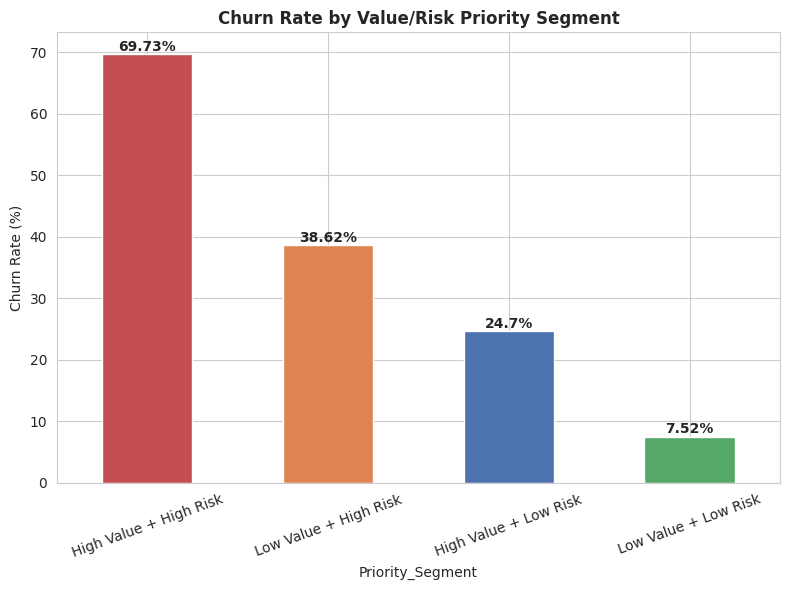


High Value + High Risk customers: 816 (11.59% of customer base)


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_map = {'High Value + High Risk': '#C44E52', 'Low Value + High Risk': '#DD8452',
              'High Value + Low Risk': '#4C72B0', 'Low Value + Low Risk': '#55A868'}
bar_colors = [colors_map.get(idx, '#888888') for idx in priority_summary.index]
priority_summary['churn_rate_pct'].plot(kind='bar', ax=ax, color=bar_colors)
ax.set_title('Churn Rate by Value/Risk Priority Segment', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(priority_summary['churn_rate_pct']):
    ax.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

high_value_high_risk_count = (df['Priority_Segment'] == 'High Value + High Risk').sum()
print(f"\nHigh Value + High Risk customers: {high_value_high_risk_count} "
      f"({high_value_high_risk_count/len(df)*100:.2f}% of customer base)")


**Observation:** "High Value + High Risk" customers — those paying above the median
monthly charge, on month-to-month contracts, within their first year of tenure — have a churn rate
far above the overall average and represent a meaningful share of the customer base.

**Business Interpretation:** This is the single group the business should prioritize immediately:
they generate above-average revenue per customer but are the least secured against leaving. This
priority framework (High/Low Value x High/Low Risk) is carried into Task 5's retention strategy and
high-value-at-risk customer list.

## 12. Save Segmented Dataset

In [12]:
output_cols = list(df.columns)
df[output_cols].to_csv('Task_3_Segmented_Dataset.csv', index=False)
print(f"Saved Task_3_Segmented_Dataset.csv with shape {df.shape}")


Saved Task_3_Segmented_Dataset.csv with shape (7043, 27)


## 13. Segment-Level Insights and Recommendations

| Segment | Churn Risk | Recommendation |
|---|---|---|
| New (0-12mo) + Month-to-month + High charges | Highest | Priority outreach within first 90 days; offer contract-lock-in incentive |
| Fiber optic + Electronic check + No support add-ons | High | Bundle TechSupport/OnlineSecurity into onboarding offer; promote autopay migration |
| Established/Loyal (25-72mo) + One/Two year contract | Lowest | Low-touch; use as advocacy/referral base, monitor satisfaction only |
| Low Value + Low Risk | Lowest | Maintain standard service, no urgent action needed |

## 14. Task 3 Conclusion
Rule-based segmentation on tenure, monthly charges, and contract type — the three variables
specified in the project brief — cleanly separates the customer base into risk tiers. Churn risk
compounds when low tenure, high monthly charges, and a month-to-month contract occur together; the
resulting **High Value + High Risk** priority segment is the clearest actionable target for
retention investment and feeds directly into the LTV and high-risk-customer analysis in Task 5.